In [18]:
import sklearn.model_selection as model_selection
import numpy as np
import pandas as  pd

data=pd.read_csv("/home/harihara-suthan-s/ML-based-approach-to-Ebbinghaus-forgetting-curve/training/ebbinghaus_combined_2600_rows_cleaned_2.csv")


In [19]:
x=data[[
    "revision_timing",
    "session_time",
    "sleep_duration",
    "nth_revision",
    "topic_difficulty",
    "study_duration"
]]
y=data["retention"]
x_train,x_test,y_train,y_test=model_selection.train_test_split(x,y,test_size=0.2,random_state=42)

print("training_samples:",len(x_train))
print("testing_samples:",len(x_test))
print("training_labels:",len(y_train))
print("testing_labels:",len(y_test))

training_samples: 2400
testing_samples: 600
training_labels: 2400
testing_labels: 600


In [20]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
print("Mean Squared Error:",mean_squared_error(y_test,y_pred))
print("R^2 Score:",r2_score(y_test,y_pred))
print("Mean Absolute Error:",mean_absolute_error(y_test,y_pred))

Mean Squared Error: 374.15970836840944
R^2 Score: 0.5966016712668165
Mean Absolute Error: 16.100201491143245


In [21]:
coeff_df=pd.DataFrame(model.coef_,x.columns,columns=["Coefficient"])
print(coeff_df.sort_values(by="Coefficient",ascending=False))

                  Coefficient
nth_revision         1.817539
sleep_duration       1.133232
study_duration       0.031720
session_time        -0.028084
revision_timing     -0.190507
topic_difficulty    -0.910951


In [22]:
from sklearn.ensemble import RandomForestRegressor

model_2=RandomForestRegressor(n_estimators=100,random_state=42)
model_2.fit(x_train,y_train)
y_pred_2=model_2.predict(x_test)
print("Mean Squared Error:",mean_squared_error(y_test,y_pred_2))
print("R^2 Score:",r2_score(y_test,y_pred_2))
print("Mean Absolute Error:",mean_absolute_error(y_test,y_pred_2))

Mean Squared Error: 29.70406018029163
R^2 Score: 0.9679747231855304
Mean Absolute Error: 4.33299008440156


In [23]:
import_df=pd.DataFrame({"Feature":x.columns,"Importance":model_2.feature_importances_})
print(import_df.sort_values(by="Importance",ascending=False))

            Feature  Importance
0   revision_timing    0.917828
3      nth_revision    0.045372
2    sleep_duration    0.013197
4  topic_difficulty    0.012978
5    study_duration    0.008041
1      session_time    0.002584


In [24]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(x_train,y_train)

y_pred_xgb=xgb.predict(x_test)



In [25]:
#evaluation
print("Mean Squared Error:",mean_squared_error(y_test,y_pred_xgb))
print("R^2 Score:",r2_score(y_test,y_pred_xgb))
print("Mean Absolute Error:",mean_absolute_error(y_test,y_pred_xgb))

Mean Squared Error: 25.71468262812088
R^2 Score: 0.9722758496864277
Mean Absolute Error: 4.009347886111517


In [26]:
#feature importance
import_df_xgb=pd.DataFrame({"Feature":x.columns,"Importance":xgb.feature_importances_})
print(import_df_xgb.sort_values(by="Importance",ascending=False))

            Feature  Importance
0   revision_timing    0.853600
3      nth_revision    0.095329
4  topic_difficulty    0.027344
2    sleep_duration    0.011234
5    study_duration    0.006444
1      session_time    0.006049


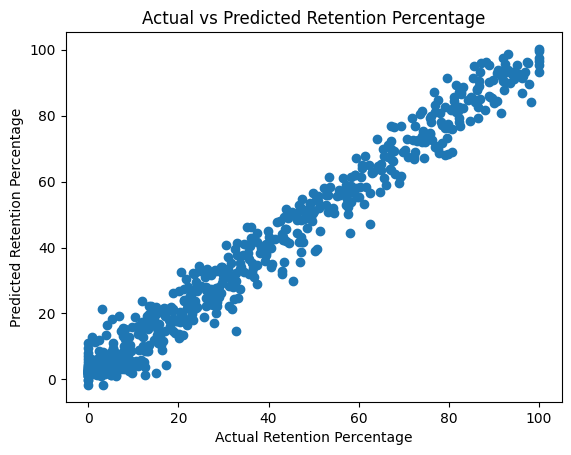

In [27]:
import matplotlib.pyplot as plt

plt.scatter(y_test,y_pred_xgb)
plt.xlabel("Actual Retention Percentage")
plt.ylabel("Predicted Retention Percentage")
plt.title("Actual vs Predicted Retention Percentage")
plt.show()

RESIDUAL ANALYSIS

Text(0.5, 1.0, 'Residual Plot')

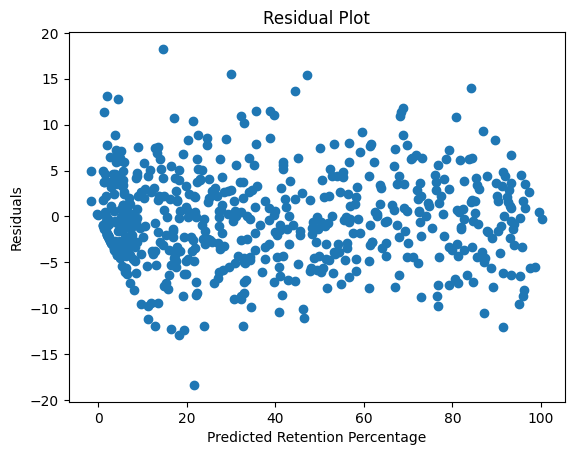

In [28]:
residuals=y_test-y_pred_xgb
plt.scatter(y_pred_xgb,residuals)
plt.xlabel("Predicted Retention Percentage")
plt.ylabel("Residuals")
plt.title("Residual Plot")

In [29]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    xgb,
    x,
    y,
    cv=5,
    scoring="r2"
)

print(scores)
print("Mean R²:", scores.mean())
print("Std:", scores.std())

[0.97081323 0.97429309 0.97146868 0.96945706 0.97282773]
Mean R²: 0.971771957051439
Std: 0.0016637709438380647


import model

In [30]:
import joblib
joblib.dump(xgb,"retention_predictor.pkl")

['retention_predictor.pkl']

In [31]:
data.head(5)

,revision_timing,nth_revision,sleep_duration,topic_difficulty,study_duration,session_time,retention
0,56.312171,7,7.190609,7,85.791568,2,61.106404
1,2.495917,1,8.053991,6,10.132390,3,98.713498
2,24.313371,9,6.673295,9,59.508954,2,72.257539
3,436.835946,2,5.677234,4,110.710477,2,0.000000
4,235.882474,6,4.193669,7,12.255043,0,0.247996
